 # Wpływ pandemii COVID-19 na dynamikę rynku pracy w latach 2015-2024

## Wczytanie bibliotek

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

## Wczytanie i przygotowanie danych

In [56]:
df = pd.read_csv('rynek_pracy.csv', sep=';')

In [57]:
df.head()

,Kod,Nazwa,Miejsca pracy,Rok,Wartosc,Jednostka miary,Atrybut,Unnamed: 7
0,0,POLSKA,nowo utworzone miejsca pracy,2015,"595,8",tys. msc.,NaN,NaN
1,0,POLSKA,nowo utworzone miejsca pracy,2016,"618,7",tys. msc.,NaN,NaN
2,0,POLSKA,nowo utworzone miejsca pracy,2017,"694,1",tys. msc.,NaN,NaN
3,0,POLSKA,nowo utworzone miejsca pracy,2018,"717,8",tys. msc.,NaN,NaN
4,0,POLSKA,nowo utworzone miejsca pracy,2019,"674,8",tys. msc.,NaN,NaN


In [58]:
df.columns = df.columns.str.replace(' ', '_').str.lower() # Zamiana spacji na podkreślenia i konwersja do małych liter
df = df.rename(columns={'nazwa': 'wojewodztwo'})  # Zmiana nazwy kolumny 'nazwa' na 'wojewodztwo'
df['wojewodztwo'] = df['wojewodztwo'].str.lower()  # Konwersja wartości w kolumnie 'wojewodztwo' do małych liter
df['wartosc'] = df['wartosc'].str.replace(',', '.').astype(float) # Zamiana przecinków na kropki i konwersja do typu float
df = df[df['wojewodztwo'] != 'polska']  # Usunięcie wiersza z wartością 'polska' w kolumnie 'wojewodztwo'

#### Sprawdzenie braku danych 

In [59]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print(f'{col}: {round(pct_missing*100)}%')


kod: 0%
wojewodztwo: 0%
miejsca_pracy: 0%
rok: 0%
wartosc: 0%
jednostka_miary: 0%
atrybut: 100%
unnamed:_7: 100%


#### Wyświetlenie unikalnych wartośi dla każdej kolumny (oprócz 'wartosc')

In [60]:
for col in df.columns:
    if col == 'wartosc':
        continue
    unique_values = df[col].unique()
    print(f'{col}: {unique_values}')
    print('---')

kod: [ 200000  400000  600000  800000 1000000 1200000 1400000 1600000 1800000
 2000000 2200000 2400000 2600000 2800000 3000000 3200000]
---
wojewodztwo: <StringArray>
[       'dolnośląskie',  'kujawsko-pomorskie',           'lubelskie',
            'lubuskie',             'łódzkie',         'małopolskie',
         'mazowieckie',            'opolskie',        'podkarpackie',
           'podlaskie',           'pomorskie',             'śląskie',
      'świętokrzyskie', 'warmińsko-mazurskie',       'wielkopolskie',
  'zachodniopomorskie']
Length: 16, dtype: str
---
miejsca_pracy: <StringArray>
['nowo utworzone miejsca pracy', 'zlikwidowane miejsca pracy']
Length: 2, dtype: str
---
rok: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
---
jednostka_miary: <StringArray>
['tys. msc.']
Length: 1, dtype: str
---
atrybut: <StringArray>
[nan, 'v']
Length: 2, dtype: str
---
unnamed:_7: [nan]
---


W ramach wstepnego przygotowania danych, podjęto decyzję o usunięciu komun `kod`, `jednostka_miary`, `atrybut`, `unnamed_7`. Zmienne te zostały uznane za nieistotne dla celów analizy, ponieważ:

* **kod** - stanowi identyfikator techniczny, który nie wnosi żadnej dodatkowej wiedzy ponad to, co oferuje kolumna 'wojewodztwo'

* **jednostka_miary** - posiada tylko jedną unikalną wartość ('tys. msc.'), co czyni ją nieistotną

* **unnamed:_7 oraz arybut** - zawierają główne braki danych (NaN). 

In [61]:
df = df.drop(['kod', 'jednostka_miary', 'atrybut', 'unnamed:_7'], axis=1)

In [62]:
df.head()

,wojewodztwo,miejsca_pracy,rok,wartosc
20,dolnośląskie,nowo utworzone miejsca pracy,2015,47.9
21,dolnośląskie,nowo utworzone miejsca pracy,2016,51.3
22,dolnośląskie,nowo utworzone miejsca pracy,2017,57.6
23,dolnośląskie,nowo utworzone miejsca pracy,2018,47.6
24,dolnośląskie,nowo utworzone miejsca pracy,2019,51.5


#### Przygotowanie tabeli przystawnej, która agreguje dane. Dzięki rozdzieleniu kolumny `miejsca_pracy` na dwie osobne kolumny, będzie można bezpośrednio porówanć dane w czasie i regionie.

In [63]:
pivot = df.pivot_table(index=['wojewodztwo','rok'], columns='miejsca_pracy',values='wartosc').reset_index() 

pivot

miejsca_pracy,wojewodztwo,rok,nowo utworzone miejsca pracy,zlikwidowane miejsca pracy
0,dolnośląskie,2015,47.9,21.9
1,dolnośląskie,2016,51.3,18.0
2,dolnośląskie,2017,57.6,20.7
3,dolnośląskie,2018,47.6,17.6
4,dolnośląskie,2019,51.5,22.5
...,...,...,...,...
155,świętokrzyskie,2020,8.2,7.0
156,świętokrzyskie,2021,12.0,6.5
157,świętokrzyskie,2022,10.5,5.0
158,świętokrzyskie,2023,9.2,5.3


In [64]:
pivot.columns = ['wojewodztwo','rok','nowe','zlikwidowane'] # Zmiana nazw kolumn na bardziej czytelne
pivot['bilans'] = pivot['nowe'] - pivot['zlikwidowane'] 
pivot.head(10)

,wojewodztwo,rok,nowe,zlikwidowane,bilans
0,dolnośląskie,2015,47.9,21.9,26.0
1,dolnośląskie,2016,51.3,18.0,33.3
2,dolnośląskie,2017,57.6,20.7,36.9
3,dolnośląskie,2018,47.6,17.6,30.0
4,dolnośląskie,2019,51.5,22.5,29.0
5,dolnośląskie,2020,45.4,22.2,23.2
6,dolnośląskie,2021,46.9,19.5,27.4
7,dolnośląskie,2022,40.0,23.8,16.2
8,dolnośląskie,2023,33.2,18.3,14.9
9,dolnośląskie,2024,34.2,24.9,9.3


## Statystyka opisowa

In [72]:
print(pivot.groupby('wojewodztwo')['bilans'].describe().round(2).sort_values('mean', ascending=False))

                     count   mean    std   min    25%    50%    75%   max
wojewodztwo                                                              
mazowieckie           10.0  64.84  19.69  31.5  59.35  64.50  70.78  95.8
śląskie               10.0  33.43  11.32  15.9  26.30  30.40  40.97  50.7
małopolskie           10.0  33.00  10.03  17.1  24.83  33.25  41.85  47.1
wielkopolskie         10.0  32.90  12.72  15.5  21.10  36.30  38.30  51.2
dolnośląskie          10.0  24.62   8.73   9.3  17.95  26.70  29.75  36.9
łódzkie               10.0  17.75   7.61   8.6  11.18  16.90  22.10  31.3
pomorskie             10.0  17.67   5.57   7.9  14.25  19.20  22.18  24.4
kujawsko-pomorskie    10.0  11.41   3.91   4.4   8.95  11.95  13.75  18.2
podkarpackie          10.0  10.79   4.92   1.4   8.07  10.60  14.02  18.0
lubelskie             10.0  10.77   4.86   2.2   7.18  12.20  14.85  16.2
zachodniopomorskie    10.0   9.98   4.33   3.4   6.40  10.10  12.78  17.5
podlaskie             10.0   6.35   1.

In [77]:
pivot[pivot['bilans'] == max(pivot['bilans'])]

,wojewodztwo,rok,nowe,zlikwidowane,bilans
43,mazowieckie,2018,151.7,55.9,95.8


**Ranking województw**

* Województwo *mazowieckie* jest liderem zestawienia, wyprzedzając pozostałe regiony z ogromną przewagą. Średnia wartość bilansu miejsc pracy w tym regionie wynosi aż 64,84 tys., a najwyższy odnotowany wynik sięgnął 95,8 tys.
    * Nowo powstałe miejsca pracy: 151,7 tys.
    * Zlikwidowane miejsca pracy: 55,9 tys.
    * Bilans: 95,8 tys.

In [66]:
idx = pivot.groupby('wojewodztwo')['bilans'].idxmin()

maximum_rows = pivot.loc[idx].sort_values('bilans', ascending=False).reset_index(drop=True)

maximum_rows

,wojewodztwo,rok,nowe,zlikwidowane,bilans
0,mazowieckie,2020,98.0,66.5,31.5
1,małopolskie,2020,49.5,32.4,17.1
2,śląskie,2020,53.6,37.7,15.9
3,wielkopolskie,2020,43.7,28.2,15.5
4,dolnośląskie,2024,34.2,24.9,9.3
5,łódzkie,2020,29.3,20.7,8.6
6,pomorskie,2020,28.4,20.5,7.9
7,kujawsko-pomorskie,2024,17.0,12.6,4.4
8,zachodniopomorskie,2020,15.9,12.5,3.4
9,podlaskie,2020,9.8,7.4,2.4


In [67]:
pre_covid = pivot[pivot['rok'].isin([2017,2018,2019])].groupby('wojewodztwo')['bilans'].mean()

covid_2020 = pivot[pivot['rok'] == 2020].set_index('wojewodztwo')['bilans']

odpornosc = (covid_2020/pre_covid).sort_values(ascending=False)

print("Współczynnik odporności regionalnej:")
print(odpornosc)

Współczynnik odporności regionalnej:
wojewodztwo
dolnośląskie           0.725756
kujawsko-pomorskie     0.619048
małopolskie            0.384558
warmińsko-mazurskie    0.373272
mazowieckie            0.365429
pomorskie              0.349043
śląskie                0.336627
wielkopolskie          0.336226
łódzkie                0.322904
podlaskie              0.314410
zachodniopomorskie     0.232877
lubelskie              0.146993
świętokrzyskie         0.143426
podkarpackie           0.086777
lubuskie              -0.016129
opolskie              -0.132743
Name: bilans, dtype: float64


In [68]:
bilans_2019 = pivot[pivot['rok']==2019].set_index('wojewodztwo')['bilans']
bilans_2021 = pivot[pivot['rok']==2021].set_index('wojewodztwo')['bilans']

recovery_coeff = ( bilans_2021/ bilans_2019).sort_values(ascending=False)   # Obliczenie proporcji: Wynikiem jest liczba, która mówi, jaki procent przedpandemicznego wyniku (z 2019 roku) osiągnęło dane województwo w 2021 roku.
print("Ranking tempa odmrażania rynku pracy (2021 vs 2019):")
print(recovery_coeff)


Ranking tempa odmrażania rynku pracy (2021 vs 2019):
wojewodztwo
opolskie               1.805556
kujawsko-pomorskie     1.162393
podlaskie              1.133333
warmińsko-mazurskie    1.118644
wielkopolskie          0.986979
mazowieckie            0.964986
podkarpackie           0.950704
dolnośląskie           0.944828
lubuskie               0.924242
śląskie                0.921053
lubelskie              0.919753
pomorskie              0.880383
świętokrzyskie         0.859375
małopolskie            0.788506
zachodniopomorskie     0.777778
łódzkie                0.706070
Name: bilans, dtype: float64


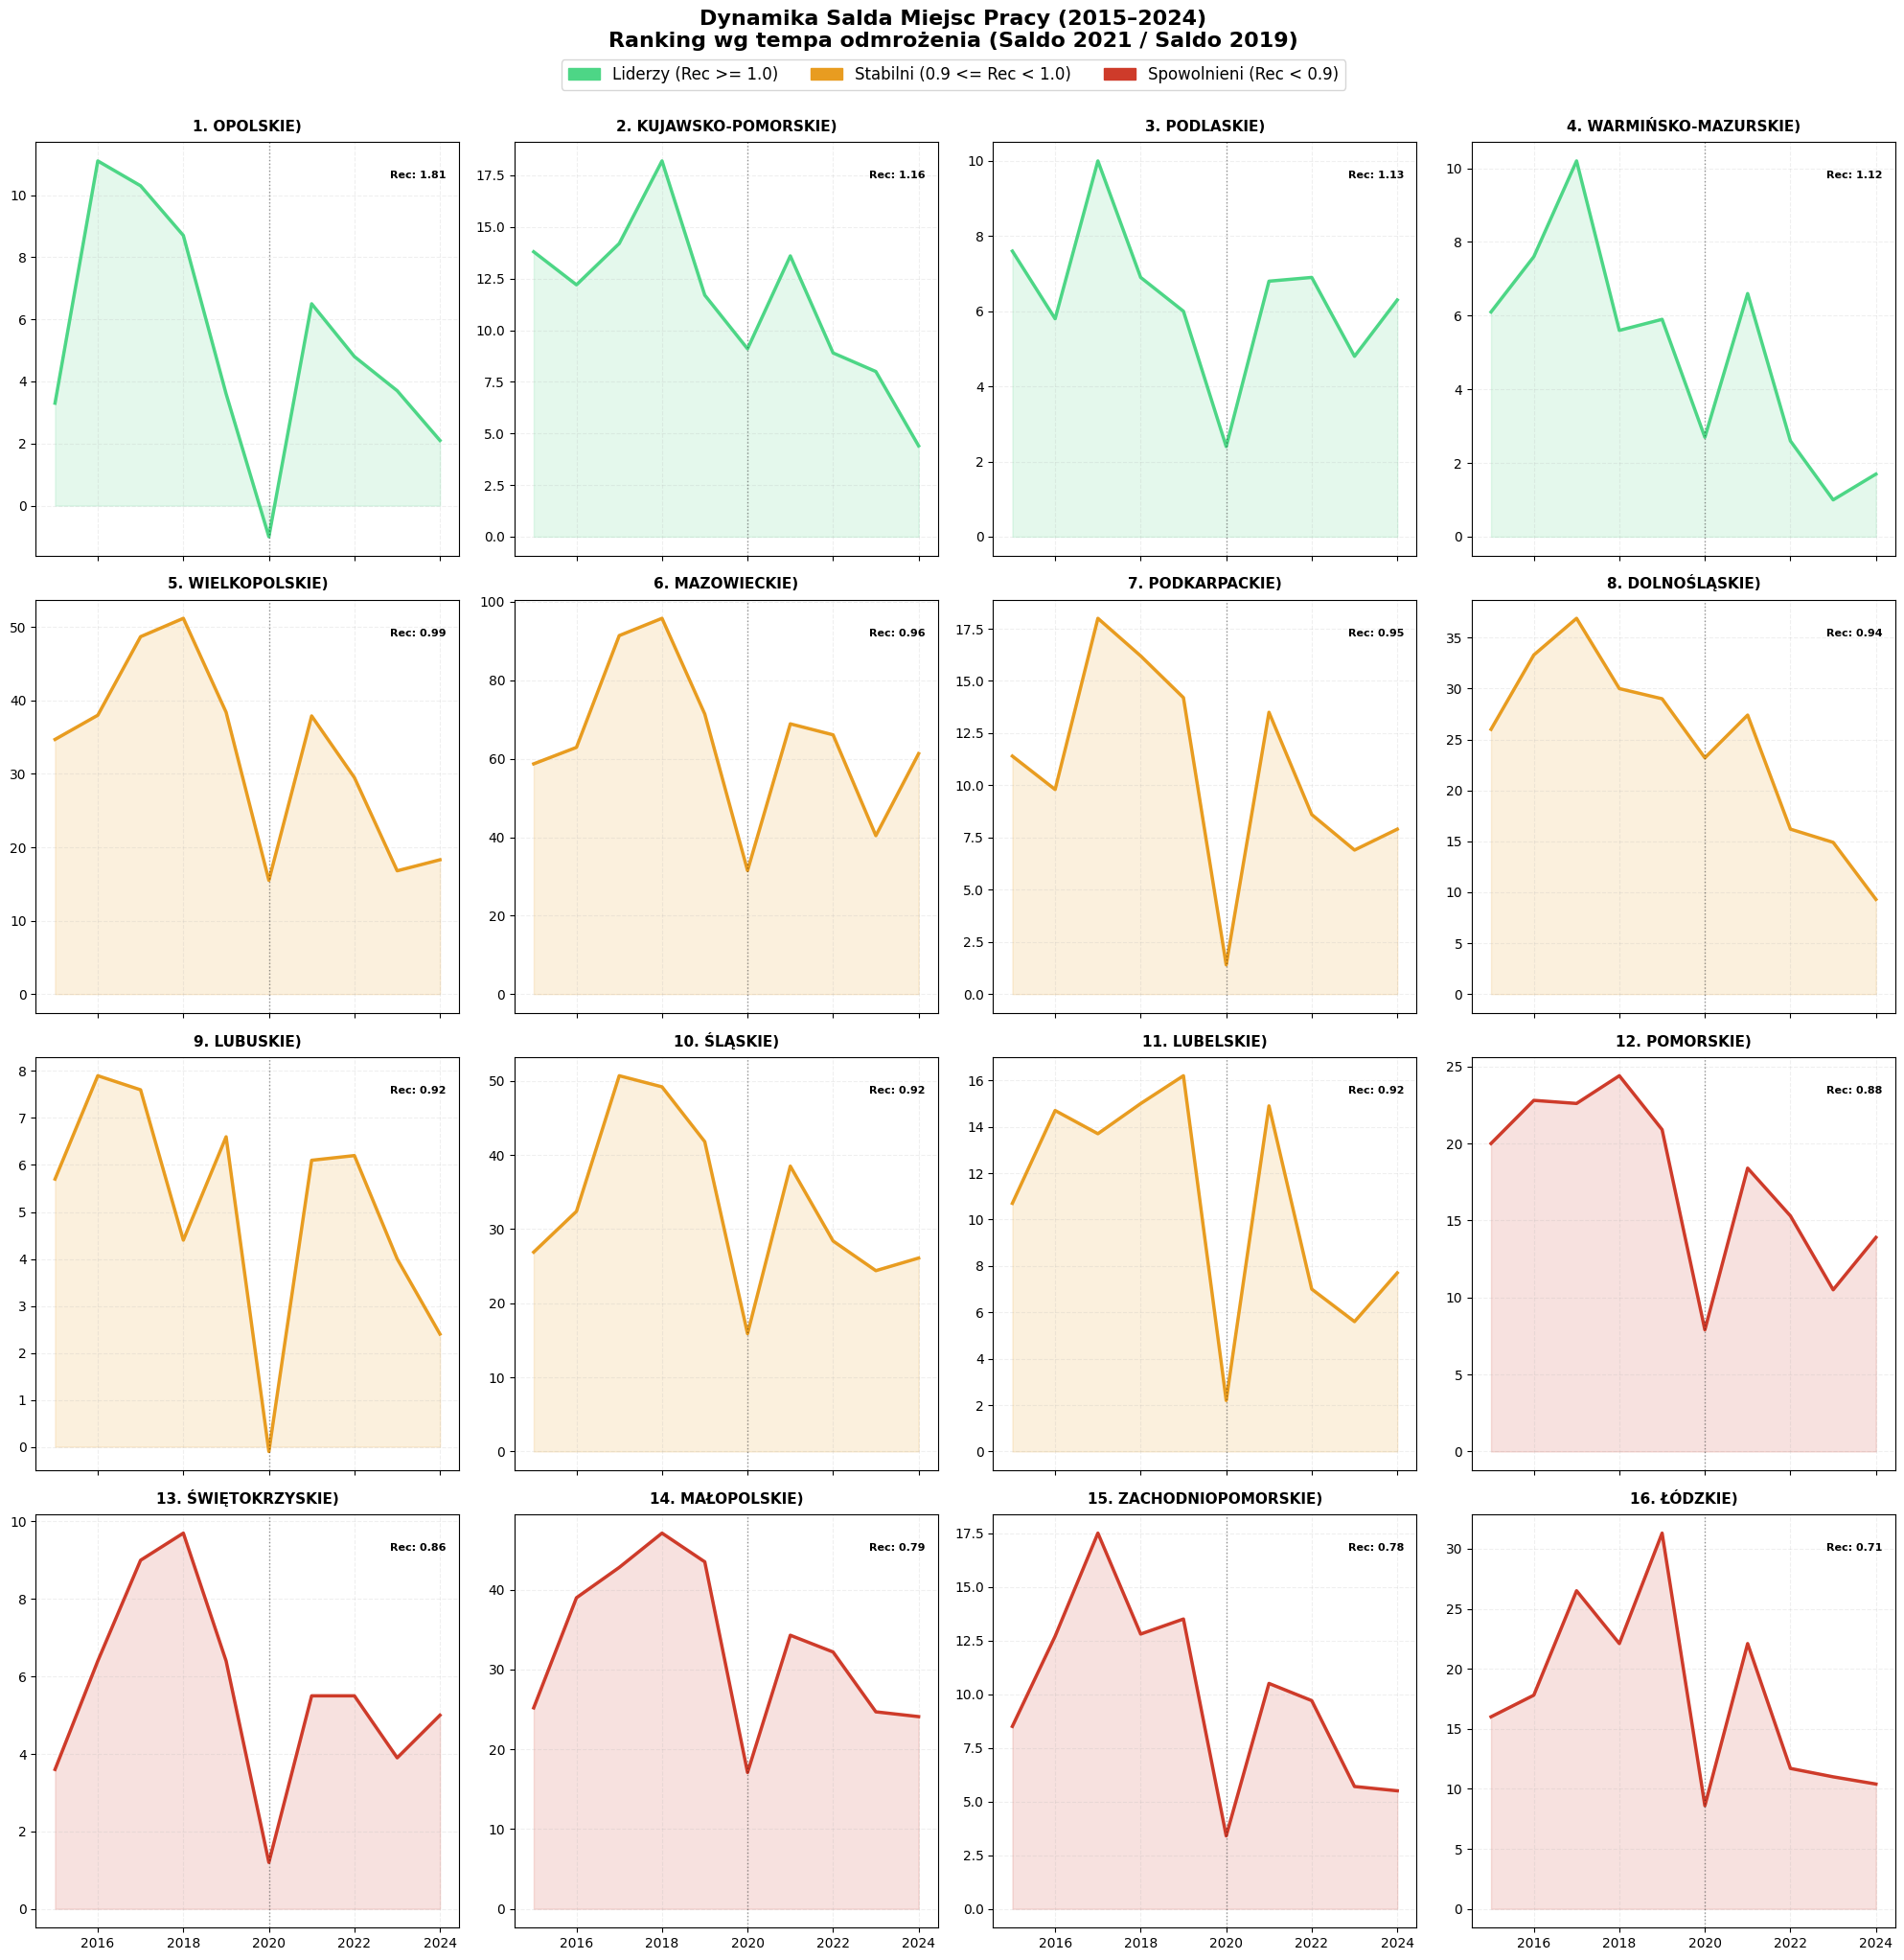

In [69]:
sorted_wojewodztwa = recovery_coeff.index.tolist()


fig, axes = plt.subplots(4, 4, figsize=(20, 20), sharex=True)
axes_flat = axes.flatten()

for i, woj in enumerate(sorted_wojewodztwa):
    sub = pivot[pivot['wojewodztwo'] == woj]
    ax = axes_flat[i]
    

    coeff = recovery_coeff[woj]
    
   
    if coeff >= 1.0:
        color_theme = '#4dd686'  
        group_label = "Liderzy"
    elif coeff >= 0.9:
        color_theme = '#e89c20'  
        group_label = "Stabilni"
    else:
        color_theme = '#ce3b2a'  
        group_label = "Spowolnieni"
    
    
    ax.fill_between(sub['rok'], sub['bilans'], alpha=0.15, color=color_theme)
    ax.plot(sub['rok'], sub['bilans'], linewidth=2.5, color=color_theme)
    
    
    ax.axvline(x=2020, color='black', linestyle=':', linewidth=1, alpha=0.4)
    ax.set_title(f'{i+1}. {woj.upper()})', fontsize=11, fontweight='bold', pad=8)
    ax.grid(alpha=0.2, linestyle='--')
    
    
    ax.text(0.97, 0.93, f'Rec: {coeff:.2f}', transform=ax.transAxes, 
            fontsize=8, ha='right', va='top', fontweight='bold')


plt.suptitle('Dynamika Salda Miejsc Pracy (2015–2024)\nRanking wg tempa odmrożenia (Saldo 2021 / Saldo 2019)', 
             fontweight='bold', fontsize=16, y=1.02)

liderzy_patch = mpatches.Patch(color="#4dd686", label='Liderzy (Rec >= 1.0)')
sredni_patch = mpatches.Patch(color="#e89c20", label='Stabilni (0.9 <= Rec < 1.0)')
maruderzy_patch = mpatches.Patch(color="#ce3b2a", label='Spowolnieni (Rec < 0.9)')

fig.legend(handles=[liderzy_patch, sredni_patch, maruderzy_patch], loc='upper center', 
           bbox_to_anchor=(0.5, 0.998), ncol=3, fontsize=12)

plt.tight_layout()
plt.show()